In [1]:
import json
import glob
import re
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
# Load all results_*.json files
all_records = []
for filepath in sorted(glob.glob("results_*.json")):
    with open(filepath) as f:
        data = json.load(f)
        all_records.extend(data)
        print(f"{filepath}: {len(data)} records")
print(f"Total: {len(all_records)} records")

results_1776081725.json: 66 records
results_1776088784.json: 27 records
results_1776090951.json: 238 records
Total: 331 records


In [3]:
def shorten_query(q):
    """Create a short readable label from a query string."""
    q = re.sub(r"\s+INTO\s+\w+", "", q, flags=re.IGNORECASE)
    q = re.sub(r'VARSIZED\("([^"]+)"\)', r'"\1"', q)
    q = re.sub(r'INT32\((\d+)\)', r'\1', q)
    q = re.sub(r'FLOAT64\(([\d.]+)\)', r'\1', q)
    q = re.sub(r'\s+', ' ', q).strip()
    return q

# File sizes for throughput calculation
BID_FILE_SIZE = 6678514674   # bytes
PERSON_FILE_SIZE = 880941057 # bytes

def get_file_size(query):
    """Return file size based on source table used in the query."""
    q_lower = query.lower()
    if "bid" in q_lower:
        return BID_FILE_SIZE
    return PERSON_FILE_SIZE

# Build dataframe with execution time and throughput
rows = []
for r in all_records:
    if r.get("status") != "Stopped" or not r.get("started") or not r.get("stopped"):
        continue
    started = datetime.strptime(r["started"], "%Y-%m-%d %H:%M:%S.%f")
    stopped = datetime.strptime(r["stopped"], "%Y-%m-%d %H:%M:%S.%f")
    exec_time = (stopped - started).total_seconds()
    query = shorten_query(r["query"].strip())
    file_size = get_file_size(query)
    throughput = file_size / exec_time  # bytes/s
    rows.append({
        "query": query,
        "threads": r["threads_number"],
        "buffer_size": r["buffer_size"],
        "exec_time_s": exec_time,
        "throughput_MBs": throughput / (1024 * 1024),  # MB/s
    })

df = pd.DataFrame(rows)
print(f"Shape: {df.shape}")
print(f"Thread counts: {sorted(df['threads'].unique())}")
print(f"Buffer sizes: {sorted(df['buffer_size'].unique())}")
print(f"Queries ({len(df['query'].unique())}):")
for q in sorted(df['query'].unique()):
    src = "bid" if "bid" in q.lower() else "person"
    print(f"  [{src}] {q}")
df.head()

Shape: (331, 5)
Thread counts: [np.int64(2), np.int64(4), np.int64(8), np.int64(16)]
Buffer sizes: [np.int64(4096), np.int64(8192), np.int64(16384), np.int64(32768), np.int64(65536), np.int64(131072), np.int64(262144), np.int64(524288), np.int64(1048576)]
Queries (10):
  [person] SELECT * FROM person WHERE city == "redmond"
  [bid] SELECT auctionId FROM bid
  [bid] SELECT auctionId FROM bid WHERE bidder == 1001
  [bid] SELECT auctionId FROM bid WHERE price = 220.0
  [bid] SELECT auctionId, price FROM bid WHERE auctionId % 123 = 0
  [person] SELECT extra FROM person
  [person] SELECT id FROM person WHERE CONCAT(city, state) == "redmondwy"
  [person] SELECT id FROM person WHERE city == "redmond"
  [person] SELECT id FROM person WHERE city == "redmond" AND state == "wy"
  [person] SELECT name FROM person WHERE city == "redmond"


,query,threads,buffer_size,exec_time_s,throughput_MBs
0,"SELECT name FROM person WHERE city == ""redmond""",2,4096,23.982,35.031726
1,"SELECT * FROM person WHERE city == ""redmond""",2,4096,20.385,41.213189
2,"SELECT id FROM person WHERE city == ""redmond""",2,4096,23.895,35.159274
3,SELECT auctionId FROM bid WHERE bidder == 1001,2,4096,248.763,25.603196
4,SELECT auctionId FROM bid,2,4096,230.247,27.662154


/var/folders/5q/dbr9j9yn6mx2tncn72pbq10h0000gn/T/ipykernel_34422/2813757795.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(thread_counts))


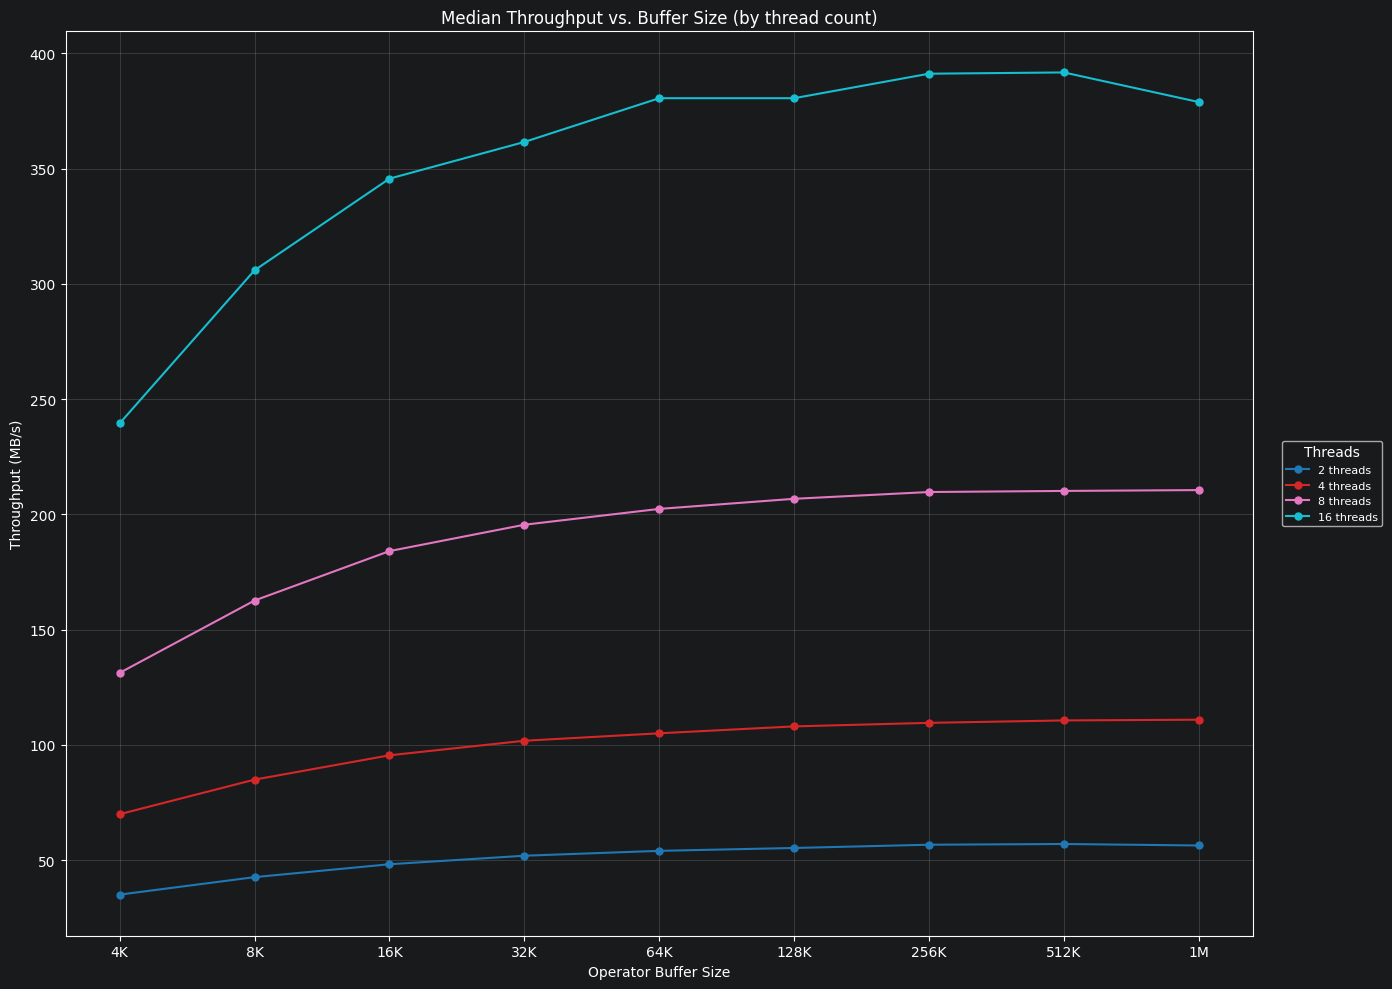

In [6]:
# Median throughput across all queries, x=buffer_size, lines=threads
def fmt_buf(x, _):
    if x >= 1048576:
        return f"{int(x/1048576)}M"
    if x >= 1024:
        return f"{int(x/1024)}K"
    return str(int(x))

thread_counts = sorted(df["threads"].unique())
cmap = plt.cm.get_cmap("tab10", len(thread_counts))
colors = {t: cmap(i) for i, t in enumerate(thread_counts)}

fig, ax = plt.subplots(figsize=(14, 10))

for t in thread_counts:
    t_data = df[df["threads"] == t]
    grouped = t_data.groupby("buffer_size")["throughput_MBs"].median().sort_index()
    ax.plot(grouped.index, grouped.values, marker="o",
            label=f"{t} threads", color=colors[t],
            linewidth=1.5, markersize=5)

ax.set_xscale("log", base=2)
ax.set_xlabel("Operator Buffer Size")
ax.set_ylabel("Throughput (MB/s)")
ax.set_title("Median Throughput vs. Buffer Size (by thread count)")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(fmt_buf))
ax.grid(True, alpha=0.3)
ax.legend(title="Threads", fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()
plt.show()

In [5]:
# Summary table: median throughput (MB/s) per buffer_size x threads
summary = df.groupby(["buffer_size", "threads"])["throughput_MBs"].median().unstack()
summary.columns = [f"{int(c)} threads" for c in summary.columns]
summary.index = [fmt_buf(i, None) for i in summary.index]
summary.round(2)

,2 threads,4 threads,8 threads,16 threads
4K,35.03,69.92,131.21,239.42
8K,42.61,84.90,162.60,305.84
16K,48.20,95.46,184.04,345.59
32K,51.90,101.77,195.47,361.50
64K,54.02,105.00,202.34,380.49
128K,55.26,108.00,206.73,380.49
256K,56.68,109.53,209.67,391.12
512K,56.99,110.59,210.14,391.67
1M,56.34,110.91,210.51,378.83
